In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import butter, filtfilt
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import r2_score, mean_squared_error

### Convert .txt files to .csv

In [27]:
folder = r"C:\Users\lmicklem\Documents\GitHub\Muscle_Sensory\Muscle_length_sensory\18-03-2026 Length Characterisation\31-03-2026 Length Characterisation"

for s in range(29, 31):       # S029 to S030
    for p in range(1, 6):    # P001 to P005
        
        filename = f"S{s:03d}P{p:03d}.txt"
        input_path = os.path.join(folder, filename)
        
        if not os.path.exists(input_path):
            print(f"Missing: {filename}")
            continue
        
        # print(f"Processing: {filename}")
        
        df = pd.read_csv(input_path, skipinitialspace=True)
        
        # Drop any accidental header rows that got read as data
        df = df[df[df.columns[0]] != 'MS']
        
        # Reset index after dropping
        df = df.reset_index(drop=True)
        
        # Now safely convert
        for col in df.columns[:2]:
            df[col] = df[col].astype(int).astype(str).str.zfill(3)
        
        # Rename third column to 't (ms)'
        cols = list(df.columns)
        cols[2] = 't (ms)'
        df.columns = cols
        
        # Save as CSV (same folder)
        output_filename = filename.replace('.txt', '.csv')
        output_path = os.path.join(folder, output_filename)
        
        df.to_csv(output_path, index=False)

### Tare time 

In [29]:
for s in range(29, 31):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            print(f"Missing: {filename}")
            continue
        
        # print(f"Processing: {filename}")
        
        df = pd.read_csv(file_path)
        
        # Ensure 't (s)' is numeric
        time_col = pd.to_numeric(df['t (ms)'], errors='coerce')
        
        # Get first value (equivalent to C2)
        t0 = time_col.iloc[0]
        
        # Create relative time column
        df['t_rel(s)'] = (time_col - t0)/1000
        
        # Save back to same file
        df.to_csv(file_path, index=False)

In [31]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

### Calculate Velocity, Strain, Strain rate, Filter Voltage, dV/dt

In [35]:
L0 = 0.155  # initial length in meters

# SavGol parameters (tune if needed)
WINDOW = 21   # must be odd
POLY   = 3

for s in range(29, 31):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            print(f"Missing: {filename}")
            continue
        
        # print(f"Processing: {filename}")
        
        df = pd.read_csv(file_path)
        
        # Clean column names (removes accidental spaces)
        df.columns = df.columns.str.strip()
        
        # --- Ensure numeric ---
        disp = pd.to_numeric(df['Displacement (mm)'], errors='coerce')
        time = pd.to_numeric(df['t_rel(s)'], errors='coerce')
        lw_raw   = pd.to_numeric(df['LW (V)'], errors='coerce')  # 

        # --- Strain ---
        strain = disp / (1000 * L0)

        # --- Sampling frequency ---
        dt_mean = np.mean(np.diff(time))
        fs = 1 / dt_mean if dt_mean > 0 else 1
        
        # --- Butterworth filter ---
        cutoff = 2  # Hz (tune this)
        disp_filtered = butter_lowpass_filter(disp, cutoff, fs)
        
        # Replace displacement with filtered version for calculations
        disp = pd.Series(disp_filtered)

        # --- Rename raw LW column ---
        df.rename(columns={'LW (V)': 'LW raw(V)'}, inplace=True)

        # --- SavGol filter ---
        # Ensure window is valid
        window = min(WINDOW, len(lw_raw) if len(lw_raw)%2==1 else len(lw_raw)-1)
        if window < 3:
            lw_filt = lw_raw.copy()
        else:
            lw_filt = savgol_filter(lw_raw, window_length=window, polyorder=POLY)
        
        df['LW (V)'] = lw_filt  # filtered signal        
        
        # --- Central differences ---
        delta_d = disp.shift(-1) - disp.shift(1)      # mm
        delta_t = time.shift(-1) - time.shift(1)      # s
        
        # Convert displacement to meters
        delta_d_m = delta_d / 1000
        
        # Velocity
        vel = delta_d_m / delta_t
        
        # Handle edges (first and last rows)
        delta_d_m.iloc[0] = 0
        delta_d_m.iloc[-1] = 0
        delta_t.iloc[0] = 0
        delta_t.iloc[-1] = 0
        vel.iloc[0] = 0
        vel.iloc[-1] = 0
        
        # Clean NaN / inf
        vel = vel.replace([float('inf'), -float('inf')], 0).fillna(0)
        delta_d_m = delta_d_m.fillna(0)
        delta_t = delta_t.fillna(0)
        
        # --- Central difference for strain rate ---
        dstrain = strain.shift(-1) - strain.shift(1)
        dt = time.shift(-1) - time.shift(1)
        
        strain_rate = dstrain / dt
        
        # Handle edges
        strain.iloc[0] = 0
        strain_rate.iloc[0] = 0
        strain_rate.iloc[-1] = 0
        
        # Clean NaN / inf
        strain = strain.fillna(0)
        strain_rate = strain_rate.replace([float('inf'), -float('inf')], 0).fillna(0)

         # --- dv/dt RAW ---
        dv_raw = lw_raw.shift(-1) - lw_raw.shift(1)
        dt_v = time.shift(-1) - time.shift(1)
        
        dvdt_raw = dv_raw / dt_v
        dvdt_raw.iloc[[0, -1]] = 0
        dvdt_raw = dvdt_raw.replace([float('inf'), -float('inf')], 0).fillna(0)

        # --- dv/dt FILTERED ---
        lw_series = pd.Series(lw_filt)
        dv = lw_series.shift(-1) - lw_series.shift(1)
        
        dvdt = dv / dt_v
        dvdt.iloc[[0, -1]] = 0
        dvdt = dvdt.replace([float('inf'), -float('inf')], 0).fillna(0)

        # --- Add columns ---
        df['delta d (m)'] = delta_d_m
        df['delta t (s)'] = delta_t
        df['vel (m/s)'] = vel
        df['strain'] = strain
        df['strain rate (1/s)'] = strain_rate
        
        df['dv/dt raw'] = dvdt_raw
        df['dv/dt'] = dvdt
        
        # Save back
        df.to_csv(file_path, index=False)

### Read and Plot Data functions

In [37]:
def load_and_average(S_value, folder_path):
    data_list = []
    
    for p in range(1, 6):
        P_value = f"{p:03d}"
        filename = f"S{S_value}P{P_value}.csv"
        filepath = os.path.join(folder_path, filename)
        
        if not os.path.exists(filepath):
            print(f"Missing file: {filename}")
            continue
        
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()
        
        time = df['t_rel(s)'].values
        disp = df['Displacement (mm)'].values 
        vel  = df['vel (m/s)'].values
        lw   = df['LW (V)'].values
        dvdt = df['dv/dt'].values  # <-- NEW

        # Sampling frequency
        dt_mean = np.mean(np.diff(time))
        fs = 1 / dt_mean if dt_mean > 0 else 1
        
        # Filter displacement
        disp = butter_lowpass_filter(disp, cutoff=2, fs=fs)
        
        # Convert to meters AFTER filtering
        disp = disp / 1000 # m 
        
        data_list.append((time, disp, vel, lw, dvdt))
    
    # --- Common time base ---
    common_time = np.linspace(
        0,
        min(t[-1] for t, *_ in data_list),
        1000
    )
    
    disp_i, vel_i, lw_i, dvdt_i = [], [], [], []
    
    for time, disp, vel, lw, dvdt in data_list:
        disp_i.append(np.interp(common_time, time, disp))
        vel_i.append(np.interp(common_time, time, vel))
        lw_i.append(np.interp(common_time, time, lw))
        dvdt_i.append(np.interp(common_time, time, dvdt))
    
    disp_i = np.array(disp_i)
    vel_i  = np.array(vel_i)
    lw_i   = np.array(lw_i)
    dvdt_i = np.array(dvdt_i)
    
    avg_disp = np.mean(disp_i, axis=0)
    avg_vel  = np.mean(vel_i, axis=0)
    avg_lw   = np.mean(lw_i, axis=0)
    avg_dvdt = np.mean(dvdt_i, axis=0)
    
    return common_time, avg_disp, avg_vel, avg_lw, avg_dvdt


def plot_results(time, disp, vel, lw, dvdt, S_value):
    fig, ax1 = plt.subplots()

    # --- Displacement (primary) ---
    l1, = ax1.plot(time, disp/L0, label='Strain')
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Strain (m)")
    ax1.grid(True)

    # # --- Velocity ---
    # ax2 = ax1.twinx()
    # l2, = ax2.plot(time, vel, label='Velocity', color = 'k')
    # ax2.set_ylabel("Velocity (m/s)")

    # --- LW ---
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    l3, = ax3.plot(time, lw, linestyle='--', label='LW (V)', color = 'r')
    ax3.set_ylabel("LW (V)")

    # # --- dv/dt (NEW) ---
    # ax4 = ax1.twinx()
    # ax4.spines["right"].set_position(("outward", 120))
    # l4, = ax4.plot(time, dvdt, linestyle='--', label='dv/dt', color = 'g')
    # ax4.set_ylabel("dv/dt (V/s)")

    plt.title(f"S{S_value} Average (P001–P005)")

    # Combined legend
    lines = [l1, l2, l3, l4]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels)

    plt.show()

NameError: name 'l2' is not defined

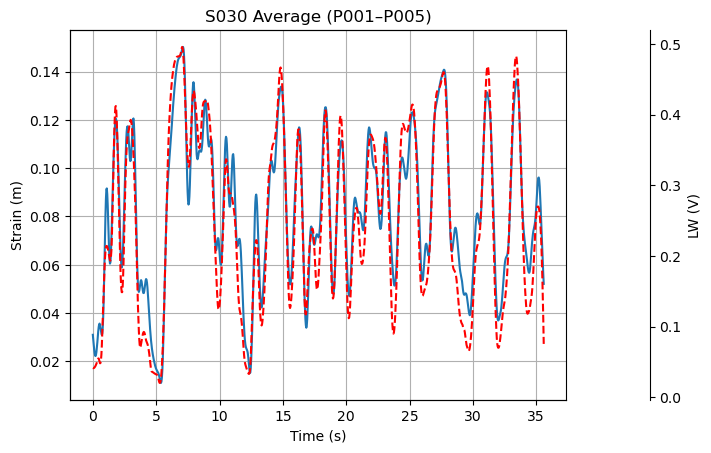

In [43]:
S_value = "030"

time, disp, vel, lw, dvdt = load_and_average(S_value, folder)
plot_results(time, disp, vel, lw, dvdt, S_value)

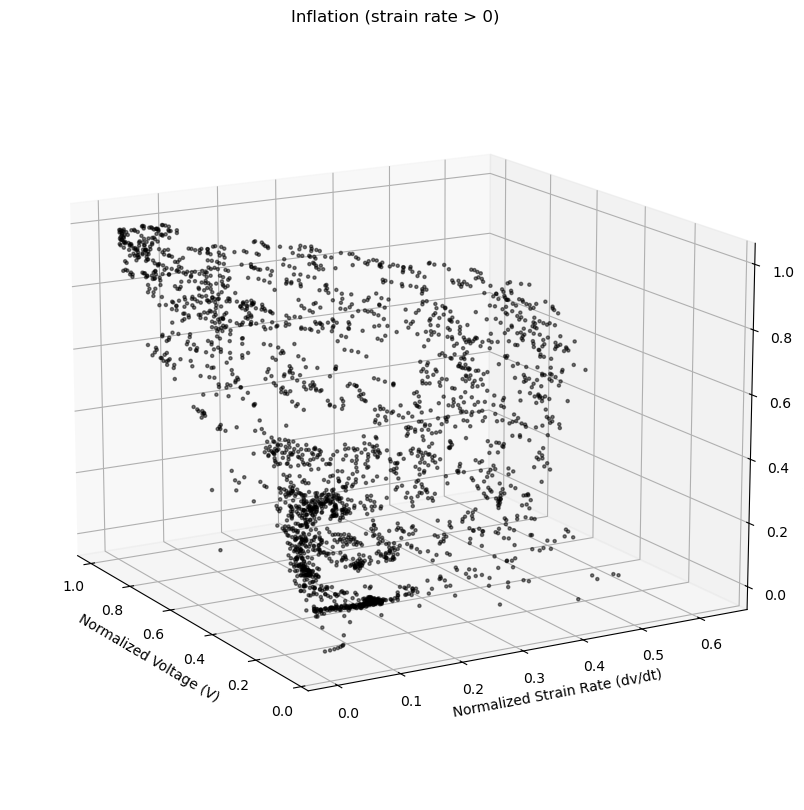

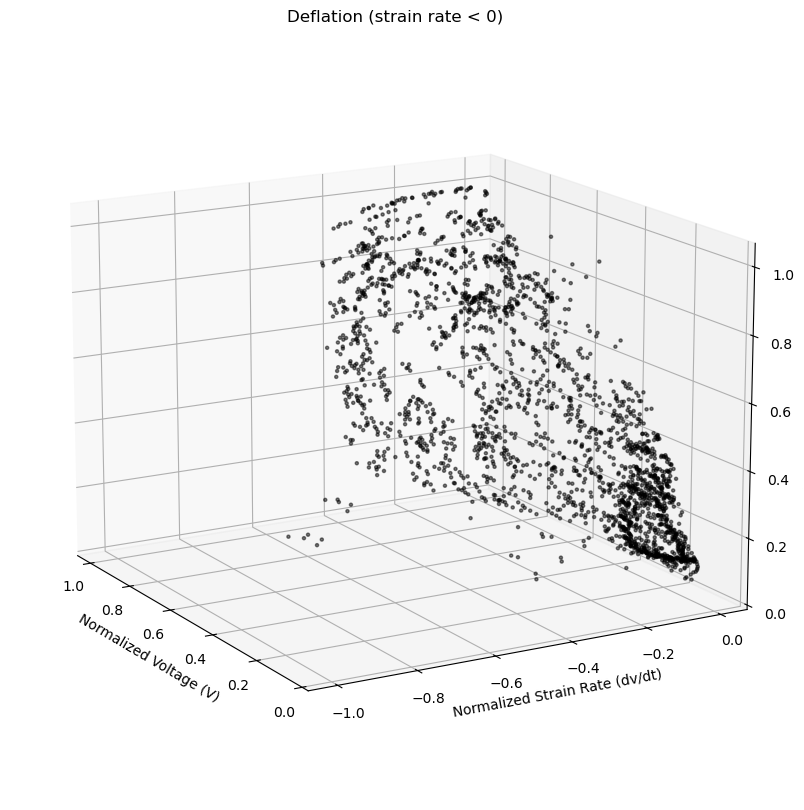

In [75]:
all_strain = []
all_dvdt = []
all_voltage = []

# --- Load all data ---
for s in range(29, 31):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            continue
        
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        strain = pd.to_numeric(df['strain'], errors='coerce')
        dvdt = pd.to_numeric(df['dv/dt'], errors='coerce')
        voltage = pd.to_numeric(df['LW (V)'], errors='coerce')
        
        valid = ~(strain.isna() | dvdt.isna() | voltage.isna())
        
        all_strain.append(strain[valid].values)
        all_dvdt.append(dvdt[valid].values)
        all_voltage.append(voltage[valid].values)

# --- Combine ---
all_strain = np.concatenate(all_strain)
all_dvdt = np.concatenate(all_dvdt)
all_voltage = np.concatenate(all_voltage)

# --- Normalize ---
strain_norm = all_strain / np.max(all_strain)

# Normalize strain rate (preserve sign)
max_sr = np.max(np.abs(all_dvdt))
dvdt_norm = all_dvdt / max_sr

# --- Normalize voltage ---
v_min = np.min(all_voltage)
v_max = np.max(all_voltage)

voltage_norm = (all_voltage - v_min) / (v_max - v_min)

# --- Split inflation / deflation ---
inflation_mask = dvdt_norm > 0
deflation_mask = dvdt_norm < 0

# =========================
# Inflation Plot
# =========================
fig1 = plt.figure(figsize = (10,10))
ax1 = fig1.add_subplot(111, projection='3d')

ax1.scatter(
    voltage_norm[inflation_mask],       # x (normalized voltage)
    dvdt_norm[inflation_mask],   # y
    strain_norm[inflation_mask],        # z
    s=5,
    alpha=0.5,
    c='black'
)

ax1.set_xlabel("Normalized Voltage (V)")
ax1.set_ylabel("Normalized Strain Rate (dv/dt)")
ax1.set_zlabel("Normalized Strain")
ax1.set_title("Inflation (strain rate > 0)")

# Invert voltage axis
ax1.invert_xaxis()
ax1.view_init(elev=15, azim=-30) #

# =========================
# Deflation Plot
# =========================
fig2 = plt.figure(figsize = (10,10))
ax2 = fig2.add_subplot(111, projection='3d')

ax2.scatter(
    voltage_norm[deflation_mask],
    dvdt_norm[deflation_mask],
    strain_norm[deflation_mask],
    s=5,
    alpha=0.5,
    c='black'
)

ax2.set_xlabel("Normalized Voltage (V)")
ax2.set_ylabel("Normalized Strain Rate (dv/dt)")
ax2.set_zlabel("Normalized Strain")
ax2.set_title("Deflation (strain rate < 0)")

# Invert voltage axis
ax2.invert_xaxis()
ax2.view_init(elev=15, azim=-30) #

plt.show()

RMSE: 0.1822675114840283
MAE : 0.15463044068489795
R2  : -21.66447118761795


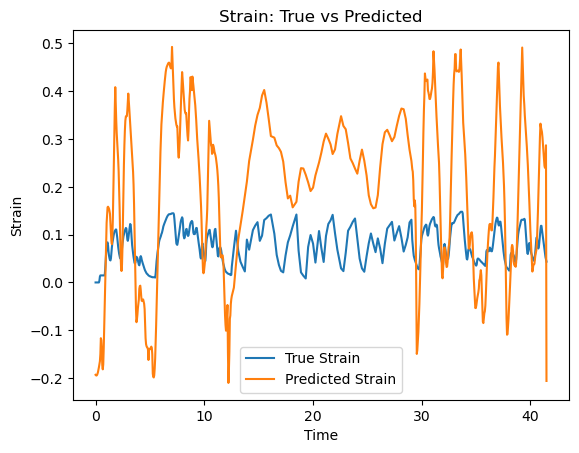

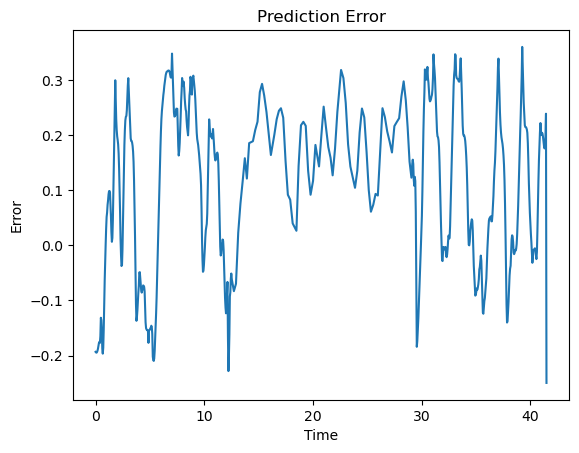

In [71]:
threshold = 1e-5  # switching deadband

strain = disp / (1000 * L0)
V = lw
dVdt = dvdt

strain_inf = (
    2.0954*V**3
    - 3.4049*V**2
    + 2.4985*V
    - 0.1611*dVdt
    - 0.0822*(V*dVdt)
    + 0.1437*(V**2 * dVdt)
    - 0.1882
)

strain_def = (
    1.5867*V**3
    - 2.7460*V**2
    + 2.3177*V
    - 0.3350*dVdt
    + 1.6647*(V*dVdt)
    - 1.3999*(V**2 * dVdt)
    - 0.1663
)

# ================================
# DYNAMIC SWITCHING
# ================================
inflating = dVdt > threshold
deflating = dVdt < -threshold

strain_pred = np.zeros(len(V))
mode = 1 if dVdt[0] >= 0 else -1  # 1 = inflation, -1 = deflation

for i in range(len(V)):
    if inflating[i]:
        mode = 1
    elif deflating[i]:
        mode = -1
    
    strain_pred[i] = strain_inf[i] if mode == 1 else strain_def[i]

# ================================
# ERROR + METRICS
# ================================
error = strain_pred - strain

rmse = np.sqrt(np.mean(error**2))
mae = np.mean(np.abs(error))
r2 = 1 - np.sum(error**2) / np.sum((strain - strain.mean())**2)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

# ================================
# OPTIONAL PLOTS
# ================================
plt.figure()
plt.plot(time, strain, label="True Strain")
plt.plot(time, strain_pred, label="Predicted Strain")
plt.xlabel("Time")
plt.ylabel("Strain")
plt.legend()
plt.title("Strain: True vs Predicted")
plt.show()

plt.figure()
plt.plot(time, error)
plt.xlabel("Time")
plt.ylabel("Error")
plt.title("Prediction Error")
plt.show()

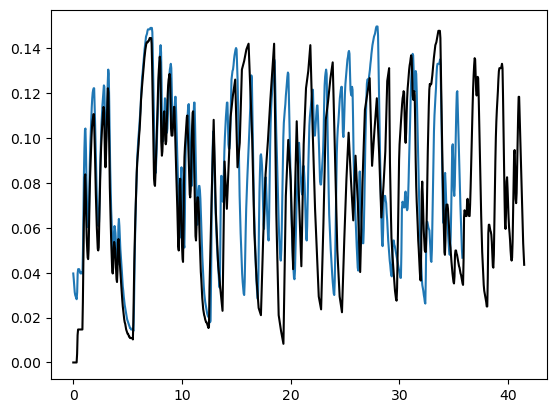

In [73]:
filename = f"S030P001.csv"
filepath = os.path.join(folder, filename)

df1 = pd.read_csv(filepath)
df1.columns = df1.columns.str.strip()

time = df1['t_rel(s)'].values
disp = df1['Displacement (mm)'].values 
vel  = df1['vel (m/s)'].values
lw   = df1['LW (V)'].values
dvdt = df1['dv/dt'].values  # <-- NEW

filename2 = f"S030P005.csv"
filepath2 = os.path.join(folder, filename2)

df2 = pd.read_csv(filepath2)
df2.columns = df1.columns.str.strip()

time2 = df2['t_rel(s)'].values
disp2 = df2['Displacement (mm)'].values 
vel2  = df2['vel (m/s)'].values
lw2   = df2['LW (V)'].values
dvdt2 = df2['dv/dt'].values  # <-- NEW

plt.plot(time2, disp2/(1000 * L0))
plt.plot(time, disp/(1000 * L0), color = 'k')
# plt.plot(time, lw)